In [1]:
import numpy as np
import os 
import sys

from format_chronic_stim import load_all_stim_times
from preprocess.spikesort_utils import ks4_preprocess, split_by_stim, get_global_spks
sys.path.append("..//neural")
from format_waveform_data import map_contacts_to_intan
sys.path.append("..//utils")
import load_matlab_data

import spikeinterface as si # core only
import spikeinterface.extractors as se
import spikeinterface.preprocessing as spre
import spikeinterface.sorters as ss
import spikeinterface.exporters as sexp
from probeinterface import get_probe

import dartsort

import probeinterface.plotting as prb_plotting
import dartsort.vis as dartvis
import matplotlib.pyplot as plt

C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\dartsort\clustering\mixture.py:108: UserWarning: Your PyTorch version (2.5.1+cu121) is supported by dartsort, but dartsort would be faster if you had >= 2.6.0.
  warnings.warn(


In [2]:
''' File paths '''
root_dir = "C:/Users/Isabel/Documents/data_temp/"

# session params
bird_id = "SLV132"
session_id = "250310"
ephys_id = "SLV132_250310_122522"

# path to .rhd intan file
intan_folder = f"{root_dir}{bird_id}_{session_id}/{ephys_id}/"

# path to various info files
map_file_path = 'Z:/Isabel/ephys/SILICON PROBE MAP H10_spikesort.xlsx'
stim_data_path = f"{intan_folder}raw_ephys_output/"

# output folders for dartsort and phy
output_folder = f"{intan_folder}dartsort/"
if os.path.isdir(output_folder):
    print('output folder exists')
else:
    os.mkdir(output_folder)

output folder exists


In [3]:
''' Load the recording file '''
# raw neural data
recording = se.read_intan(f"{intan_folder}info.rhd", stream_id='0')

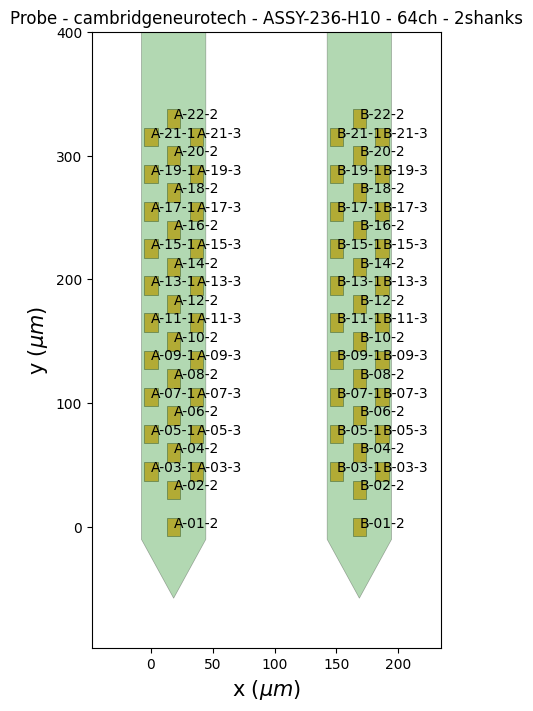

In [4]:
''' Add the probe map and check channel layout '''
# load the probe layout
probe = get_probe(manufacturer="cambridgeneurotech", probe_name="ASSY-236-H10")

# map to intan
contact_sort, ch_names, shank_idx = map_contacts_to_intan(probe, map_file_path)
probe = probe.get_slice(contact_sort)

# visualize to check
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
prb_plotting.plot_probe(probe, ax=ax)
ylims = ax.get_ylim()
ax.set_ylim(ylims[0], 400)
for pos, ch_name in zip(probe.contact_positions, ch_names):
    ax.text(pos[0], pos[1], ch_name)

In [5]:
# set the channel indices in the probe object
n_channels = contact_sort.shape[0]
probe.set_device_channel_indices(np.arange(n_channels))

# add the probe map and channel names
recording = recording.set_probe(probe)
recording.set_property("channel_name", ch_names)
recording.set_property("group", shank_idx)

In [6]:
# split the recording by shank
recordings_by_shank = recording.split_by("group")

In [7]:
''' Preprocess similarly to kilosort4 '''
recordings_by_shank[0] = ks4_preprocess(recordings_by_shank[0])
recordings_by_shank[1] = ks4_preprocess(recordings_by_shank[1])

In [8]:
''' Separate stim/hash from spontaneous spiking '''
# load stim times
stim_t_samples = load_all_stim_times(stim_data_path)

# define the stim + hash window
pre_stim_t = 5e-3 # seconds
post_stim_t = 25e-3

# separate the recordings
recordings_A, maps_A = split_by_stim(recordings_by_shank[0], stim_t=stim_t_samples,
                                     pre_stim_t=pre_stim_t, post_stim_t=post_stim_t)
recordings_B, maps_B = split_by_stim(recordings_by_shank[1], stim_t=stim_t_samples,
                                     pre_stim_t=pre_stim_t, post_stim_t=post_stim_t)

In [9]:
''' Save as binary files for DARTsort '''
recording_spont_bin_A = recordings_A['spont'].save(format="binary", folder=f"{output_folder}spont_binary_A")
recording_stim_bin_A = recordings_A['stim'].save(format="binary", folder=f"{output_folder}stim_binary_A")
recording_spont_bin_B = recordings_B['spont'].save(format="binary", folder=f"{output_folder}spont_binary_B")
recording_stim_bin_B  = recordings_B['stim'].save(format="binary", folder=f"{output_folder}stim_binary_B")

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.66 MiB - total_memory=3.66 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/2713 [00:00<?, ?it/s]

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.66 MiB - total_memory=3.66 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/28 [00:00<?, ?it/s]

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.66 MiB - total_memory=3.66 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/2713 [00:00<?, ?it/s]

write_binary_recording 
engine=process - n_jobs=1 - samples_per_chunk=30,000 - chunk_memory=3.66 MiB - total_memory=3.66 MiB - chunk_duration=1.00s


write_binary_recording (no parallelization):   0%|          | 0/28 [00:00<?, ?it/s]

In [10]:
''' Sort the data without stim + hash '''
sorting_spont_A = dartsort.dartsort(recording_spont_bin_A, f"{output_folder}A_shank/")

# dartsort_result = dartsort.dartsort(
#     recording_spont_bin_A,
#     f"{output_folder}A_shank/",
#     cfg=dartsort.DARTsortUserConfig(
#         preprocessing="ibllike",
#         work_in_tmpdir=True,
#         copy_recording_to_tmpdir=True,
#     ),
# )

Load initial denoiser fit data:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/2713 [00:00<?, ?it/s]

Got 250115 spikes, enough to stop early.


Epochs:   0%|          | 0/100 [00:00<?, ?epoch/s]

Load examples for denoiser fitting:cuda 1.0s/it [spk/it=%%%]:   0%|          | 0/2713 [00:00<?, ?it/s]

Got 50160 spikes, enough to stop early.


...

Interpolating /collisioncleaned_tpca_features:   0%|          | 0/876 [00:00<?, ?it/s]

Interpolating /collisioncleaned_tpca_features:   0%|          | 0/876 [00:00<?, ?it/s]

KDTdens[15]:   0%|          | 0/245 [00:00<?, ?it/s]

Unable to allocate 1.91 GiB for an array with shape (256456010,) and data type int64
Traceback (most recent call last):
  File "C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\dartsort\main.py", line 181, in dartsort
    return _dartsort_impl(
           ^^^^^^^^^^^^^^^
  File "C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\dartsort\main.py", line 299, in _dartsort_impl
    sorting = cluster(
              ^^^^^^^^
  File "C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\dartsort\main.py", line 753, in cluster
    result = clusterer.cluster(
             ^^^^^^^^^^^^^^^^^^
  File "C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\dartsort\clustering\clustering.py", line 658, in cluster
    sorting = self.clusterer.cluster(
              ^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\Isabel\miniconda3\envs\spike_sort\Lib\site-packages\dartsort\clustering\clustering.py", line 658, in cluster
    sorting = self.clusterer.cluster(
              ^

MemoryError: Unable to allocate 1.91 GiB for an array with shape (256456010,) and data type int64

In [ ]:
''' Estimate the templates '''
template_data = dartsort.estimate_template_library(recording=recording_spont_bin, sorting=sorting_spont)

In [ ]:
''' Visualize sorting results - todo '''
# todo update variable names etc.

# gather outputs from dartsort
dartsort_result = dartsort(recording, output_dir, ...)
sorting = dartsort_result["sorting"]
motion = dartsort_result["motion"]

# or, if you already ran it
# sorting = dartsort.load(output_dir)
# motion = dartsort.try_load_motion_info(output_dir)

dartvis.visualize_sorting(
    recording,
    sorting,
    vis_save_dir,
    motion=motion,
    make_unit_summaries=False
)

In [ ]:
''' Find templates in stim period '''
# match the templates to the stim period
matching_stim = dartsort.match(recording=recording_stim_bin, template_data=template_data)

In [ ]:
''' Evaluate matching results - todo
check spike times/raw traces
matching_scores
matching_probs
amplitudes
residual_norms
'''
scores = matching_stim.get_property("match_score")

In [ ]:
''' Concatenate the spike times and labels from each set of recording chunks '''
# spike times and unit IDs (aligned to full recording)
spont_spike_times, spont_spike_ids = get_global_spks(sorting_spont, spont_t_map)
stim_spike_times, stim_spike_ids = get_global_spks(matching_stim, stim_t_map)

# concatenate and sort
all_spike_t = np.concatenate([spont_spike_times, stim_spike_times])
all_spike_labels = np.concatenate([spont_spike_ids, stim_spike_ids])
sort_idx = np.argsort(all_spike_t)
all_spike_labels = all_spike_labels[sort_idx]
all_spike_t = all_spike_t[sort_idx]

# create a Spike Interface sorting object to export to Phy
combined_sorting = si.NumpySorting.from_times_labels(
    times_list=[all_spike_t],
    labels_list=[all_spike_labels],
    sampling_frequency=fs,
)

# save quality metrics
combined_sorting.set_property("match_score", all_scores)
combined_sorting.set_property("match_probability", all_probs)

In [ ]:
'''
Export results + post-process
- phy compatible format
- and/or SC automated curation method?
- ultimately match key files to existing data (e.g. wfStruct)
'''
# create a sorting analyzer
analyzer = si.create_sorting_analyzer(
    sorting=combined_sorting,
    recording=recording,
    folder="analyzer",
)

# compute things for phy
analyzer.compute(['random_spikes', 'waveforms', 'templates', 'noise_levels'])
_ = analyzer.compute('principal_components', n_components = 5, mode="by_channel_local")
_ = analyzer.compute("spike_amplitudes")
_ = analyzer.compute("unit_locations")
_ = analyzer.compute("template_similarity")

# export to phy - todo
sexp.export_to_phy(analyzer, output_folder="phy_output")